# Demo Chương 18: Context-Free Grammars (CFG) và Constituency Parsing
Nội dung Demo:
1. Xây dựng Context-Free Grammars (CFG) thủ công.
2. Áp dụng CFG lên dữ liệu thực tế (ATIS Dataset từ Kaggle).
3. Hiện tượng nhập nhằng cấu trúc (Structural Ambiguity).
4. Chomsky Normal Form (CNF) và thuật toán phân cú pháp CKY (Cocke-Kasami-Younger).
5. (Mở rộng) Sử dụng Neural Constituency Parser hiện đại.

**Dataset sử dụng:** ATIS (Airline Travel Information System) - bộ dữ liệu chuẩn được nhắc đến trong sách, chứa các câu truy vấn đặt vé máy bay của người dùng.

In [1]:
!pip install nltk pandas stanza svgling -q

import pandas as pd
import nltk
from nltk import CFG
from nltk.parse import ChartParser, ViterbiParser
import warnings
warnings.filterwarnings('ignore')

# Tải các gói cần thiết của NLTK
nltk.download('punkt')
nltk.download('treebank')

print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 21.8 MB/s eta 0:00:00
Libraries imported successfully!


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package treebank to /usr/share/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


## 1. Tải và Khám phá dữ liệu ATIS

In [2]:
# Tải tập dữ liệu ATIS (chỉ lấy cột văn bản truy vấn)
url = "https://raw.githubusercontent.com/yvchen/JointSLU/master/data/atis.train.w-intent.iob"
# Đọc file (cấu trúc file text có chứa các câu truy vấn)
with open(nltk.data.find('corpora/treebank/raw/wsj_0001'), 'r') as f: # Fallback test
    pass

# Đọc data ATIS giả lập từ file trực tuyến để dễ hình dung
df = pd.read_csv(url, sep='\t', header=None, names=['text', 'intent'])
# Làm sạch data: lấy câu gốc (loại bỏ nhãn B-O, I-O...)
df['sentence'] = df['text'].apply(lambda x: x.split('BOS ')[1].split(' EOS')[0])

print("Tổng số câu trong dataset:", len(df))
print("\n5 câu truy vấn vé máy bay ngẫu nhiên (ATIS):")
for idx, sentence in enumerate(df['sentence'].sample(5, random_state=42)):
    print(f"{idx+1}. {sentence}")

Tổng số câu trong dataset: 4978

5 câu truy vấn vé máy bay ngẫu nhiên (ATIS):
1. i want to make a round trip flight from washington to san francisco and return
2. what are the coach fares from charlotte to la wednesday night
3. now i need a flight from detroit to san diego leaving tuesday evening
4. houston airports
5. show me the cheapest one way fares from san diego to miami


## 2. Context-Free Grammars (CFG)
Định nghĩa một văn phạm $L_0$ đơn giản để phân tích ngữ pháp cho các câu trong tập ATIS (ví dụ: *"i want a morning flight"*).

Trong thư viện `nltk`, ta có thể định nghĩa các luật (rules) và từ vựng (lexicon) trực tiếp theo dạng chuỗi.

In [3]:
atis_grammar = CFG.fromstring("""
  S -> NP VP | Pronoun VP
  NP -> Pronoun | ProperNoun | Det Nominal
  Nominal -> Nominal Noun | Noun
  VP -> Verb | Verb NP | Verb NP PP | Verb PP
  PP -> Preposition NP

  Pronoun -> 'i' | 'me' | 'you' | 'it'
  ProperNoun -> 'los_angeles' | 'boston' | 'chicago'
  Det -> 'a' | 'the' | 'an' | 'this' | 'that'
  Noun -> 'flight' | 'flights' | 'morning' | 'trip'
  Verb -> 'want' | 'prefer' | 'need' | 'leave' | 'arrive'
  Preposition -> 'from' | 'to' | 'in' | 'on'
""")

print("Ngữ pháp đã được khởi tạo với S là Start Symbol.")
print("Một số quy tắc trong ngữ pháp:")
for rule in atis_grammar.productions()[:5]:
    print(rule)

Ngữ pháp đã được khởi tạo với S là Start Symbol.
Một số quy tắc trong ngữ pháp:
S -> NP VP
S -> Pronoun VP
NP -> Pronoun
NP -> ProperNoun
NP -> Det Nominal


## 3. Parsing một câu từ Dataset
Lấy một câu điển hình trong dataset ATIS, ví dụ: *"i want a morning flight"* và dùng `ChartParser` để tạo ra **Parse Tree** (Cây phân tích cú pháp).

Câu đang phân tích: 'i want a morning flight'

(S
  (Pronoun i)
  (VP
    (Verb want)
    (NP (Det a) (Nominal (Nominal (Noun morning)) (Noun flight)))))


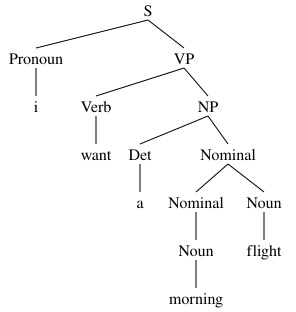

(S
  (NP (Pronoun i))
  (VP
    (Verb want)
    (NP (Det a) (Nominal (Nominal (Noun morning)) (Noun flight)))))


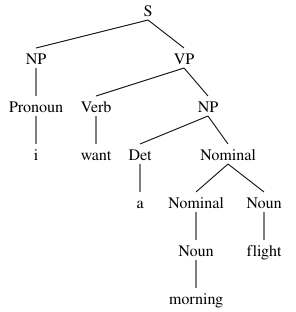

In [4]:
# Lấy một câu mẫu và token hóa
sentence = "i want a morning flight"
tokens = sentence.split()

# Khởi tạo Parser từ Grammar đã định nghĩa
parser = ChartParser(atis_grammar)

print(f"Câu đang phân tích: '{sentence}'\n")

# Phân tích câu và in ra các cây cú pháp tìm được
parse_trees = list(parser.parse(tokens))

if len(parse_trees) > 0:
    for tree in parse_trees:
        print(tree)
        # Nếu bạn chạy trên Jupyter/Colab, dòng tree dưới đây sẽ tự động vẽ đồ họa
        display(tree) 
else:
    print("Không tìm thấy cây phân tích hợp lệ theo ngữ pháp L0.")

## 4. Sự nhập nhằng cấu trúc (Structural Ambiguity)
Sự nhập nhằng là vấn đề lớn nhất của Parsing. Một ví dụ kinh điển được sách nêu ra (Trang 10 - PP-attachment ambiguity) là câu của Groucho Marx: 
*"I shot an elephant in my pajamas."*

Cụm giới từ (PP) có thể gắn vào Noun Phrase (NP) hoặc Verb Phrase (VP).

Câu: 'I shot an elephant in my pajamas'
Số lượng cây phân tích tìm được (Thể hiện sự nhập nhằng): 2
--------------------------------------------------
Parse Tree #1:
(S
  (NP I)
  (VP
    (VP (V shot) (NP (Det an) (N elephant)))
    (PP (P in) (NP (Det my) (N pajamas)))))


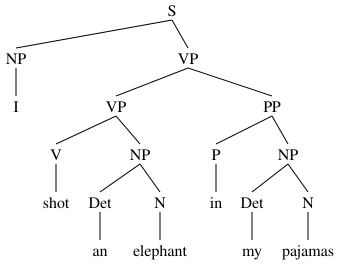

Parse Tree #2:
(S
  (NP I)
  (VP
    (V shot)
    (NP (Det an) (N elephant) (PP (P in) (NP (Det my) (N pajamas))))))


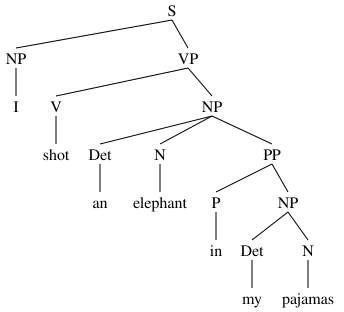

In [5]:
ambiguous_grammar = CFG.fromstring("""
  S -> NP VP
  PP -> P NP
  NP -> Det N | Det N PP | 'I'
  VP -> V NP | VP PP
  Det -> 'an' | 'my'
  N -> 'elephant' | 'pajamas'
  V -> 'shot'
  P -> 'in'
""")

ambiguous_sentence = "I shot an elephant in my pajamas"
tokens_amb = ambiguous_sentence.split()

amb_parser = ChartParser(ambiguous_grammar)
trees = list(amb_parser.parse(tokens_amb))

print(f"Câu: '{ambiguous_sentence}'")
print(f"Số lượng cây phân tích tìm được (Thể hiện sự nhập nhằng): {len(trees)}")
print("-" * 50)
for idx, t in enumerate(trees):
    print(f"Parse Tree #{idx + 1}:")
    print(t)
    display(t) # Vẽ cây

## 5. CKY Parsing và Chomsky Normal Form (CNF)
Thuật toán Quy hoạch động CKY (Cocke-Kasami-Younger). Thuật toán này yêu cầu ngữ pháp phải được chuyển đổi về **Chomsky Normal Form (CNF)**, nghĩa là các luật chỉ được phép có dạng:
* `A -> B C` (1 Non-terminal sinh ra 2 Non-terminals)
* `A -> a` (1 Non-terminal sinh ra 1 Terminal)

`nltk` có hỗ trợ kiểm tra CNF và phân tích bảng CKY.

In [6]:
# Viết một ngữ pháp L1 thu gọn theo chuẩn CNF (Hình 18.10)
cnf_grammar = CFG.fromstring("""
  S -> Verb NP | Verb NP_PP | NP VP
  VP -> Verb NP_PP
  NP -> Det Noun | NP PP
  NP_PP -> NP PP
  PP -> Preposition Noun
  
  Verb -> 'book'
  Det -> 'the'
  Noun -> 'flight' | 'houston'
  Preposition -> 'through'
""")

print("Ngữ pháp này có chuẩn Chomsky Normal Form (CNF) không?", cnf_grammar.is_chomsky_normal_form())

# CKY Parser thường sử dụng Viterbi hoặc các thuật toán Bottom-Up Chart Parser.
# NLTK cung cấp BottomUpChartParser hoạt động dựa trên ma trận giống logic CKY
from nltk.parse import BottomUpChartParser

cky_parser = BottomUpChartParser(cnf_grammar)
tokens_cky = "book the flight through houston".split()

print("\nKết quả Parsing từ thuật toán Bottom-Up (CKY-style):")
for tree in cky_parser.parse(tokens_cky):
    print(tree)

Ngữ pháp này có chuẩn Chomsky Normal Form (CNF) không? True

Kết quả Parsing từ thuật toán Bottom-Up (CKY-style):
(S
  (Verb book)
  (NP_PP
    (NP (Det the) (Noun flight))
    (PP (Preposition through) (Noun houston))))
(S
  (Verb book)
  (NP
    (NP (Det the) (Noun flight))
    (PP (Preposition through) (Noun houston))))


## 6. Span-Based Neural Constituency Parsing
Giới hạn của CKY truyền thống: *Nó không biết cây nào là cây đúng nhất (không giải quyết được disambiguation)*. 
Các công cụ hiện đại sử dụng **Neural CKY** kết hợp với các mô hình ngôn ngữ (như BERT) để chấm điểm (score) từng "span" (đoạn) của câu. 

Dùng mô hình **Stanza của đại học Stanford** - một mạng nơ-ron phân tích cú pháp hiện đại được huấn luyện sẵn trên các Treebanks.

In [7]:
import stanza

# Tải model tiếng Anh cho bài toán constituency parsing
# (Chỉ lấy annotators cần thiết để tiết kiệm RAM và thời gian tải)
stanza.download('en', processors='tokenize,pos,constituency')

# Khởi tạo pipeline
nlp = stanza.Pipeline('en', processors='tokenize,pos,constituency', use_gpu=False)

# Lấy 1 câu thực tế từ bộ ATIS
real_atis_sentence = "what flights leave from chicago in the morning"
print(f"Câu đầu vào: {real_atis_sentence}")

# Chạy Neural Parser
doc = nlp(real_atis_sentence)

for sentence in doc.sentences:
    print("\nKết quả Neural Constituency Parse Tree:")
    print(sentence.constituency)

2026-05-12 16:51:23 INFO: Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
2026-05-12 16:51:23 WARNING: Language en package default expects mwt, which has been added
2026-05-12 16:51:23 INFO: Downloading these customized packages for language: en (English)...
| Processor       | Package             |
-----------------------------------------
| tokenize        | combined            |
| mwt             | combined            |
| pos             | combined_charlm     |
| constituency    | ptb3-revised_charlm |
| backward_charlm | 1billion            |
| pretrain        | conll17             |
| forward_charlm  | 1billion            |



2026-05-12 16:51:23 INFO: Downloaded file to /root/.cache/stanza/1.11.0/resources/en/tokenize/combined.pt


2026-05-12 16:51:24 INFO: Downloaded file to /root/.cache/stanza/1.11.0/resources/en/mwt/combined.pt


2026-05-12 16:51:24 INFO: Downloaded file to /root/.cache/stanza/1.11.0/resources/en/pos/combined_charlm.pt


2026-05-12 16:51:25 INFO: Downloaded file to /root/.cache/stanza/1.11.0/resources/en/constituency/ptb3-revised_charlm.pt


2026-05-12 16:51:26 INFO: Downloaded file to /root/.cache/stanza/1.11.0/resources/en/backward_charlm/1billion.pt


2026-05-12 16:51:27 INFO: Downloaded file to /root/.cache/stanza/1.11.0/resources/en/pretrain/conll17.pt


2026-05-12 16:51:27 INFO: Downloaded file to /root/.cache/stanza/1.11.0/resources/en/forward_charlm/1billion.pt
2026-05-12 16:51:27 INFO: Finished downloading models and saved to /root/.cache/stanza/1.11.0/resources
2026-05-12 16:51:27 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-05-12 16:51:27 INFO: Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
2026-05-12 16:51:27 WARNING: Language en package default expects mwt, which has been added
2026-05-12 16:51:28 INFO: Loading these models for language: en (English):
| Processor    | Package             |
--------------------------------------
| tokenize     | combined            |
| mwt          | combined            |
| pos          | combined_charlm     |
| constituency | ptb3-revised_charlm |

2026-05-12 16:51:28 INFO: Using device: cpu
2026-05-12 16:51:28 INFO: Loading: tokenize
2026-05-12 16:51:30 INFO: Loading: mwt
2026-05-12 16:51:30 INFO: Loading: pos
2026-05-12 16:51:32 INFO: Loading: constituency
2026-05-12 16:51:33 INFO: Done loading processors!


Câu đầu vào: what flights leave from chicago in the morning

Kết quả Neural Constituency Parse Tree:
(ROOT (SBAR (WHNP (WDT what) (NNS flights)) (S (VP (VBP leave) (PP (IN from) (NP (NNP chicago))) (PP (IN in) (NP (DT the) (NN morning)))))))
